# Main Setup


In [1]:
# Importing libraries and setting the seed

import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 1000)

In [34]:
# Load dataset

df_filtered = pd.read_csv("df_filtered_cleaned.csv") 

print("filtered shape:", df_filtered.shape)

filtered shape: (32030, 3)


In [35]:
# Quick checks

print(df_filtered.columns.tolist())
print(df_filtered.head(3))

print("\nMissing values:")
print(df_filtered.isna().sum())

print("\nClass counts:")
print(df_filtered["political_leaning"].value_counts())

print("\nClass proportions:")
print(df_filtered["political_leaning"].value_counts(normalize=True))

print("\nUnique authors:", df_filtered["author_ID"].nunique())

['author_ID', 'post_cleaned', 'political_leaning']
     author_ID  \
0  t2_7ramzeng   
1  t2_7ramzeng   
2  t2_7ramzeng   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [36]:
# Main dataset for the LR experiments

df_filtered = df_filtered.copy()

In [37]:
# Author level split

unique_authors = df_filtered["author_ID"].unique()

train_authors, test_authors = train_test_split(unique_authors, test_size=0.20,random_state=SEED)

train_df = df_filtered[df_filtered["author_ID"].isin(train_authors)].copy()
test_df = df_filtered[df_filtered["author_ID"].isin(test_authors)].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain authors:", train_df["author_ID"].nunique())
print("Test authors:", test_df["author_ID"].nunique())

print( "\nAuthor overlap:", len(set(train_df["author_ID"]).intersection(set(test_df["author_ID"]))))

Train shape: (26606, 3)
Test shape: (5424, 3)

Train authors: 1036
Test authors: 259

Author overlap: 0


In [38]:
# Metrics 

def evaluate_predictions(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro",zero_division=0)

    return accuracy, precision, recall, macro_f1

In [39]:
# Final LR candidate settings

LR_CANDIDATES = [
    {
        "name": "lr_cand_023",
        "max_rows_per_author": 30,
        "word_max_features": 10000,
        "char_max_features": 20000,
        "C": 0.23
    },
    {
        "name": "lr_cand_0235",
        "max_rows_per_author": 30,
        "word_max_features": 10000,
        "char_max_features": 20000,
        "C": 0.235
    },
    {
        "name": "lr_cand_024",
        "max_rows_per_author": 30,
        "word_max_features": 10000,
        "char_max_features": 20000,
        "C": 0.24
    }
]

pd.DataFrame(LR_CANDIDATES)

,name,max_rows_per_author,word_max_features,char_max_features,C
0,lr_cand_023,30,10000,20000,0.230
1,lr_cand_0235,30,10000,20000,0.235
2,lr_cand_024,30,10000,20000,0.240


In [40]:
# Validation only model selection

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

candidate_summaries = []
candidate_fold_results = []

for candidate in LR_CANDIDATES:
    candidate_name = candidate["name"]
    max_rows_per_author = candidate["max_rows_per_author"]
    word_max_features = candidate["word_max_features"]
    char_max_features = candidate["char_max_features"]
    c_value = candidate["C"]

    train_df_capped = (
        train_df
        .groupby("author_ID", group_keys=False)
        .head(max_rows_per_author)
        .copy()
    )

    X_arr = np.array(train_df_capped["post_cleaned"].tolist(), dtype=object)
    y_arr = np.array(train_df_capped["political_leaning"].tolist(), dtype=object)
    g_arr = np.array(train_df_capped["author_ID"].tolist(), dtype=object)

    fold_rows = []

    for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(
        sgkf.split(X_arr, y_arr, g_arr),
        start=1
    ):
        X_fold_train = X_arr[fold_train_idx].tolist()
        y_fold_train = y_arr[fold_train_idx].tolist()

        X_fold_val = X_arr[fold_val_idx].tolist()
        y_fold_val = y_arr[fold_val_idx].tolist()

        word_vectorizer = TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.90,
            max_features=word_max_features,
            smooth_idf=True,
            sublinear_tf=True
        )

        char_vectorizer = TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 3),
            min_df=3,
            max_df=0.90,
            max_features=char_max_features,
            smooth_idf=True,
            sublinear_tf=True
        )

        lr_pipeline = Pipeline([
            ("features", FeatureUnion([
                ("word_tfidf", word_vectorizer),
                ("char_tfidf", char_vectorizer)
            ])),
            ("classifier", LogisticRegression(
                C=c_value,
                max_iter=3000,
                random_state=SEED,
                class_weight=None
            ))
        ])

        lr_pipeline.fit(X_fold_train, y_fold_train)

        train_pred = lr_pipeline.predict(X_fold_train)
        val_pred = lr_pipeline.predict(X_fold_val)

        train_accuracy, _, _, train_macro_f1 = evaluate_predictions(y_fold_train, train_pred)
        val_accuracy, _, _, val_macro_f1 = evaluate_predictions(y_fold_val, val_pred)

        row = {
            "candidate": candidate_name,
            "fold": fold_idx,
            "max_rows_per_author": max_rows_per_author,
            "word_max_features": word_max_features,
            "char_max_features": char_max_features,
            "C": c_value,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy,
            "train_macro_f1": train_macro_f1,
            "val_macro_f1": val_macro_f1,
            "train_val_accuracy_gap": train_accuracy - val_accuracy,
            "train_val_macro_f1_gap": train_macro_f1 - val_macro_f1
        }

        fold_rows.append(row)
        candidate_fold_results.append(row)

    fold_df = pd.DataFrame(fold_rows)

    candidate_summaries.append({
        "candidate": candidate_name,
        "max_rows_per_author": max_rows_per_author,
        "word_max_features": word_max_features,
        "char_max_features": char_max_features,
        "C": c_value,
        "mean_train_accuracy": fold_df["train_accuracy"].mean(),
        "mean_val_accuracy": fold_df["val_accuracy"].mean(),
        "mean_train_macro_f1": fold_df["train_macro_f1"].mean(),
        "mean_val_macro_f1": fold_df["val_macro_f1"].mean(),
        "mean_train_val_accuracy_gap": fold_df["train_val_accuracy_gap"].mean(),
        "mean_train_val_macro_f1_gap": fold_df["train_val_macro_f1_gap"].mean()
    })

lr_candidate_fold_results_df = pd.DataFrame(candidate_fold_results)
lr_candidate_summary_df = pd.DataFrame(candidate_summaries)

lr_candidate_summary_df = lr_candidate_summary_df.sort_values(
    by=["mean_val_macro_f1", "mean_train_val_macro_f1_gap"],
    ascending=[False, True]
)

lr_candidate_summary_df

,candidate,max_rows_per_author,word_max_features,char_max_features,C,mean_train_accuracy,mean_val_accuracy,mean_train_macro_f1,mean_val_macro_f1,mean_train_val_accuracy_gap,mean_train_val_macro_f1_gap
2,lr_cand_024,30,10000,20000,0.240,0.854682,0.666987,0.849291,0.649124,0.187694,0.200167
1,lr_cand_0235,30,10000,20000,0.235,0.853754,0.666454,0.848253,0.648271,0.187300,0.199982
0,lr_cand_023,30,10000,20000,0.230,0.851324,0.664677,0.845611,0.646151,0.186647,0.199460


In [41]:
best_lr_candidate = lr_candidate_summary_df.iloc[0].to_dict()

print("Best candidate selected using validation only:")
print(best_lr_candidate)

Best candidate selected using validation only:
{'candidate': 'lr_cand_024', 'max_rows_per_author': 30, 'word_max_features': 10000, 'char_max_features': 20000, 'C': 0.24, 'mean_train_accuracy': 0.8546816167035148, 'mean_val_accuracy': 0.6669871770004202, 'mean_train_macro_f1': 0.8492909862292549, 'mean_val_macro_f1': 0.6491239392627325, 'mean_train_val_accuracy_gap': 0.18769443970309457, 'mean_train_val_macro_f1_gap': 0.20016704696652252}


In [42]:
# Final test evaluation

best_max_rows_per_author = int(best_lr_candidate["max_rows_per_author"])
best_word_max_features = int(best_lr_candidate["word_max_features"])
best_char_max_features = int(best_lr_candidate["char_max_features"])
best_c_value = float(best_lr_candidate["C"])

train_df_capped = (
    train_df
    .groupby("author_ID", group_keys=False)
    .head(best_max_rows_per_author)
    .copy()
)

test_df_capped = (
    test_df
    .groupby("author_ID", group_keys=False)
    .head(best_max_rows_per_author)
    .copy()
)

X_train_final = train_df_capped["post_cleaned"].tolist()
y_train_final = train_df_capped["political_leaning"].tolist()

X_test_final = test_df_capped["post_cleaned"].tolist()
y_test_final = test_df_capped["political_leaning"].tolist()

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    max_features=best_word_max_features,
    smooth_idf=True,
    sublinear_tf=True
)

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 3),
    min_df=3,
    max_df=0.90,
    max_features=best_char_max_features,
    smooth_idf=True,
    sublinear_tf=True
)

lr_pipeline_final = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", word_vectorizer),
        ("char_tfidf", char_vectorizer)
    ])),
    ("classifier", LogisticRegression(
        C=best_c_value,
        max_iter=3000,
        random_state=SEED,
        class_weight=None
    ))
])

lr_pipeline_final.fit(X_train_final, y_train_final)

train_pred_final = lr_pipeline_final.predict(X_train_final)
test_pred_final = lr_pipeline_final.predict(X_test_final)

train_accuracy_final, _, _, train_macro_f1_final = evaluate_predictions(
    y_train_final,
    train_pred_final
)

test_accuracy_final, _, _, test_macro_f1_final = evaluate_predictions(
    y_test_final,
    test_pred_final
)

lr_final_selected_result = pd.DataFrame({
    "model": ["Logistic Regression"],
    "selection_rule": ["best validation-only candidate"],
    "max_rows_per_author": [best_max_rows_per_author],
    "word_max_features": [best_word_max_features],
    "char_max_features": [best_char_max_features],
    "C": [best_c_value],
    "train_accuracy": [train_accuracy_final],
    "test_accuracy": [test_accuracy_final],
    "train_macro_f1": [train_macro_f1_final],
    "test_macro_f1": [test_macro_f1_final],
    "train_test_accuracy_gap": [train_accuracy_final - test_accuracy_final],
    "train_test_macro_f1_gap": [train_macro_f1_final - test_macro_f1_final]
})

lr_final_selected_result

,model,selection_rule,max_rows_per_author,word_max_features,char_max_features,C,train_accuracy,test_accuracy,train_macro_f1,test_macro_f1,train_test_accuracy_gap,train_test_macro_f1_gap
0,Logistic Regression,best validation-only candidate,30,10000,20000,0.24,0.845562,0.69108,0.840375,0.680689,0.154482,0.159686


In [43]:
print("Test classification report:")
print(classification_report(
    y_test_final,
    test_pred_final,
    labels=["left", "right"],
    zero_division=0
))

print("\nConfusion matrix:")
print(confusion_matrix(
    y_test_final,
    test_pred_final,
    labels=["left", "right"]
))

Test classification report:
              precision    recall  f1-score   support

        left       0.72      0.55      0.62      1625
       right       0.68      0.81      0.74      1884

    accuracy                           0.69      3509
   macro avg       0.70      0.68      0.68      3509
weighted avg       0.70      0.69      0.68      3509


Confusion matrix:
[[ 896  729]
 [ 355 1529]]


# Split Visualization

In [44]:
# Data for split visualization

df_viz = df_filtered.reset_index(drop=True).copy()
df_viz["row_id"] = np.arange(len(df_viz))

print(df_viz.shape)
df_viz.head()

(32030, 4)


,author_ID,post_cleaned,political_leaning,row_id
0,t2_7ramzeng,you can buy the show and stream it through them including the lethal weapon url episode which i assume is the one he s talking about edit sorry i forgot there were two lethal weapon episodes the one with lethal weapon got pulled season episode url is not available for purchase tbh when i was younger this sort of thing bugged me but i also responded to it in the least constructive way i thought it was fun to act more creepy when i noticed that sort of thing was happening just to push that person s buttons now i just keep doing things like i normally would i m not going to lose sleep over some stranger s opinions of me we have a slackbot form that we fill out every tuesday which is basically a waste what are you working on bug what do you hope to accomplish this week bug and bug any blockers no same thing every time except different ticket numbers usually on fridays we do a zoom meeting where we go over every ticket for the sprint and talk about its status that tends to be more produ...,right,0
1,t2_7ramzeng,me want to play q bert holy shit based alex jones broken clocks i guess normally i see a t shirt i downvote and report spam i don t see any attempts to sell this one though on the other hand if this is genuine op needs to keep the watch running they ain t gonna pause the clock for you if you collapse during a race so keep it running during your training run too earn that dnf full article is paywalled but this looks like the bank is just blowing smoke up some activist s ass and not intending to actually do any tracking if they actually try to implement it they ll get plenty of false positives but people will just buy their guns with cash those questions are only useful if you ask the candidate to talk you through their solution you can tell pretty quickly if they didn t write the code themselves i d like to do it in a controlled environment though i e our current interview process involves an online coding test then a zoom call to go over the solutions we could theoretically run int...,right,1
2,t2_7ramzeng,shouldn t rely on any external services or persistent data between tests it s understandable if your ci server uses the same database server for all jobs for cost reduction reasons or whatever so if that s the database that s down it s fine that the unit tests are blocked from running there but you should still be able to write tests and run them locally on your dev machine without any of those dependencies none of this is going to be easy or quick to fix though so be ready for the long haul but if you re looking for something to do start reading up on unit testing the right way and come up with a plan to fix your organization s process one piece at a time gt interesting the unit test using a db sounds like a blend of unit test and an integration test yeah that part s true an absolute purist will tell you there s a difference between unit and integration tests i think in practice they kinda bleed together and that s ok the key things from my perspective are each test should do some...,right,2
3,t2_7ramzeng,pr to a specific person usually that just means a round robin approach where we pick the next reviewer in line but for cases where a specific person has context you assign it to that specific person other people can jump in and add their own feedback but at a minimum the assigned reviewer has to approve before it can go out it depends which ship you re on there have been mentions of primarily vulcan crewed ships with vulcan climate controls and i think andorians as well but yeah climate and other factors can be an irritant t pol complained pretty regularly about her human crewmates having bad body odor for example ds had some references to human vs cardsassian climate preferences but usually not on starfleet ships iirc early on o brian had a hard time getting ds s climate controls out of cardassian mode and up to human bajoran standards i get the impression t

In [45]:
# Numeric ids for authors

author_to_num = {
    author_id: i for i, author_id in enumerate(df_viz["author_ID"].unique())
}

df_viz["author_num"] = df_viz["author_ID"].map(author_to_num)

print("Number of unique authors:", df_viz["author_ID"].nunique())
df_viz[["row_id", "author_ID", "author_num"]].head()

Number of unique authors: 1295


,row_id,author_ID,author_num
0,0,t2_7ramzeng,0
1,1,t2_7ramzeng,0
2,2,t2_7ramzeng,0
3,3,t2_7ramzeng,0
4,4,t2_7ramzeng,0


In [46]:
# 80% strict split point

strict_split_idx = int(len(df_viz) * 0.80)

print("Strict split row index:", strict_split_idx)

Strict split row index: 25624


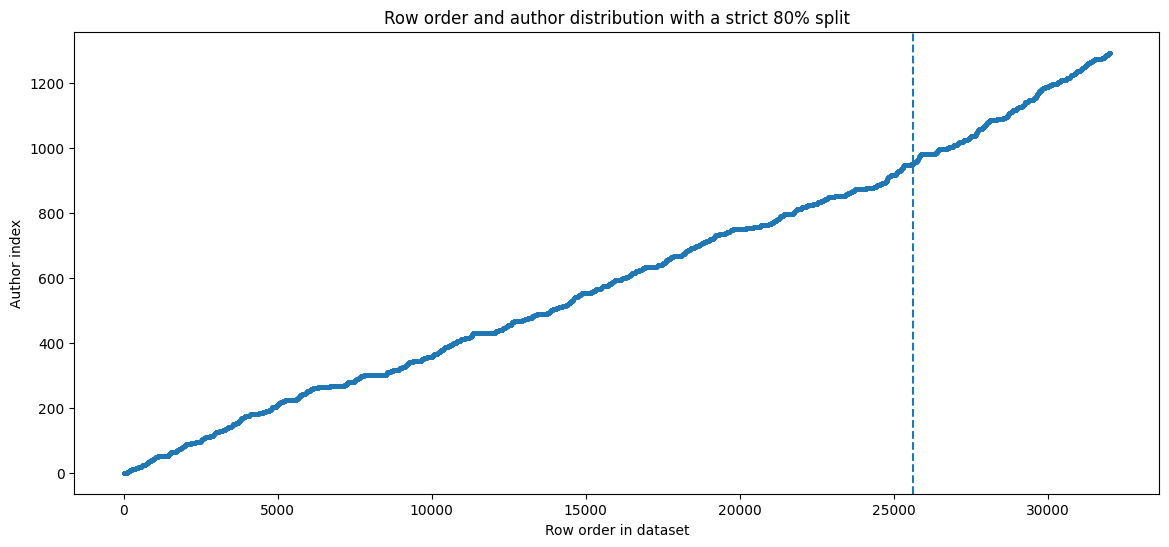

In [47]:
# Row order vs author index

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.scatter(
    df_viz["row_id"],
    df_viz["author_num"],
    s=3
)

plt.axvline(
    x=strict_split_idx,
    linestyle="--"
)

plt.xlabel("Row order in dataset")
plt.ylabel("Author index")
plt.title("Row order and author distribution with a strict 80% split")
plt.show()

In [48]:
# Author overlap under a strict row based split

strict_train_df = df_viz.iloc[:strict_split_idx].copy()
strict_test_df = df_viz.iloc[strict_split_idx:].copy()

strict_overlap = len(
    set(strict_train_df["author_ID"]).intersection(set(strict_test_df["author_ID"]))
)

print("Strict row-based split author overlap:", strict_overlap)
print("Strict train authors:", strict_train_df["author_ID"].nunique())
print("Strict test authors:", strict_test_df["author_ID"].nunique())

Strict row-based split author overlap: 1
Strict train authors: 952
Strict test authors: 344


In [49]:
# Author overlap under the author level split

author_split_overlap = len(
    set(train_df["author_ID"]).intersection(set(test_df["author_ID"]))
)

print("Author-level split author overlap:", author_split_overlap)
print("Author-level train authors:", train_df["author_ID"].nunique())
print("Author-level test authors:", test_df["author_ID"].nunique())

Author-level split author overlap: 0
Author-level train authors: 1036
Author-level test authors: 259


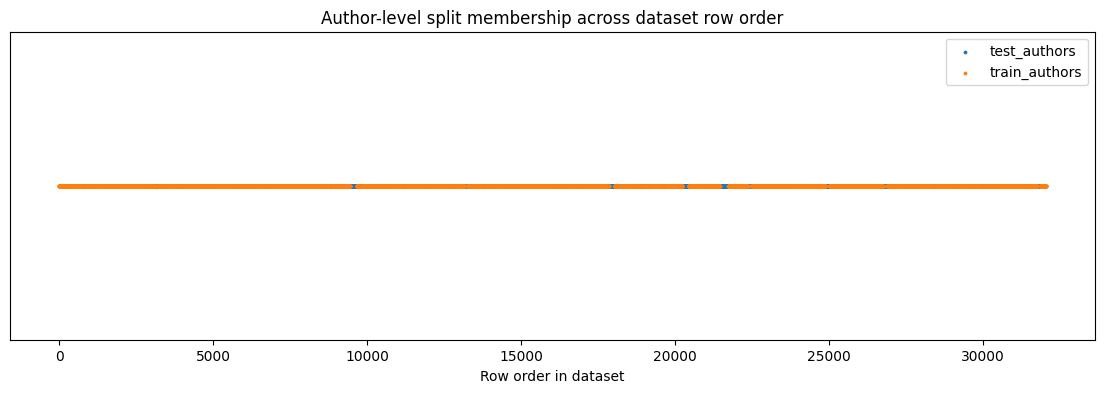

In [50]:
# Visualize author level split across row order

train_author_set = set(train_authors)
test_author_set = set(test_authors)

df_viz["author_split_group"] = df_viz["author_ID"].apply(
    lambda x: "train_authors" if x in train_author_set else "test_authors"
)

plt.figure(figsize=(14, 4))

for group_name, group_df in df_viz.groupby("author_split_group"):
    plt.scatter(
        group_df["row_id"],
        [1] * len(group_df),
        s=3,
        label=group_name
    )

plt.xlabel("Row order in dataset")
plt.yticks([])
plt.title("Author-level split membership across dataset row order")
plt.legend()
plt.show()

# Exploratory LR experiments

In [51]:
# Exploratory LR results

lr_exploratory_results = []

In [52]:
def add_exploratory_result(
    experiment_name,
    dataset_name,
    split_type,
    max_rows_per_author,
    feature_setup,
    c_value,
    class_weight,
    mean_train_accuracy,
    mean_val_accuracy,
    mean_train_macro_f1,
    mean_val_macro_f1,
    mean_train_val_accuracy_gap,
    mean_train_val_macro_f1_gap,
    final_train_accuracy,
    final_test_accuracy,
    final_train_macro_f1,
    final_test_macro_f1,
    final_train_test_accuracy_gap,
    final_train_test_macro_f1_gap,
    notes=""
):
    lr_exploratory_results.append({
        "experiment_name": experiment_name,
        "dataset_name": dataset_name,
        "split_type": split_type,
        "max_rows_per_author": max_rows_per_author,
        "feature_setup": feature_setup,
        "C": c_value,
        "class_weight": class_weight,
        "mean_train_accuracy": mean_train_accuracy,
        "mean_val_accuracy": mean_val_accuracy,
        "mean_train_macro_f1": mean_train_macro_f1,
        "mean_val_macro_f1": mean_val_macro_f1,
        "mean_train_val_accuracy_gap": mean_train_val_accuracy_gap,
        "mean_train_val_macro_f1_gap": mean_train_val_macro_f1_gap,
        "final_train_accuracy": final_train_accuracy,
        "final_test_accuracy": final_test_accuracy,
        "final_train_macro_f1": final_train_macro_f1,
        "final_test_macro_f1": final_test_macro_f1,
        "final_train_test_accuracy_gap": final_train_test_accuracy_gap,
        "final_train_test_macro_f1_gap": final_train_test_macro_f1_gap,
        "notes": notes
    })

In [53]:
def run_lr_experiment(
    experiment_name,
    max_rows_per_author,
    word_max_features,
    char_max_features,
    c_value,
    class_weight,
    use_char_features=True,
    dataset_name="df_filtered_cleaned_light.csv",
    split_type="author_level"
):
    # cap
    if max_rows_per_author is None:
        train_df_used = train_df.copy()
        test_df_used = test_df.copy()
        max_rows_label = "no_cap"
    else:
        train_df_used = (
            train_df
            .groupby("author_ID", group_keys=False)
            .head(max_rows_per_author)
            .copy()
        )

        test_df_used = (
            test_df
            .groupby("author_ID", group_keys=False)
            .head(max_rows_per_author)
            .copy()
        )

        max_rows_label = max_rows_per_author

    # validation first
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

    X_arr = np.array(train_df_used["post_cleaned"].tolist(), dtype=object)
    y_arr = np.array(train_df_used["political_leaning"].tolist(), dtype=object)
    g_arr = np.array(train_df_used["author_ID"].tolist(), dtype=object)

    fold_rows = []

    for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(
        sgkf.split(X_arr, y_arr, g_arr),
        start=1
    ):
        X_fold_train = X_arr[fold_train_idx].tolist()
        y_fold_train = y_arr[fold_train_idx].tolist()

        X_fold_val = X_arr[fold_val_idx].tolist()
        y_fold_val = y_arr[fold_val_idx].tolist()

        word_vectorizer = TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.90,
            max_features=word_max_features,
            smooth_idf=True,
            sublinear_tf=True
        )

        if use_char_features:
            char_vectorizer = TfidfVectorizer(
                analyzer="char",
                ngram_range=(3, 3),
                min_df=3,
                max_df=0.90,
                max_features=char_max_features,
                smooth_idf=True,
                sublinear_tf=True
            )

            features = FeatureUnion([
                ("word_tfidf", word_vectorizer),
                ("char_tfidf", char_vectorizer)
            ])
            feature_setup = "word_1_2 + char_3"
        else:
            features = word_vectorizer
            feature_setup = "word_1_2_only"

        lr_pipeline = Pipeline([
            ("features", features),
            ("classifier", LogisticRegression(
                C=c_value,
                max_iter=3000,
                random_state=SEED,
                class_weight=class_weight
            ))
        ])

        lr_pipeline.fit(X_fold_train, y_fold_train)

        train_pred = lr_pipeline.predict(X_fold_train)
        val_pred = lr_pipeline.predict(X_fold_val)

        train_accuracy, _, _, train_macro_f1 = evaluate_predictions(y_fold_train, train_pred)
        val_accuracy, _, _, val_macro_f1 = evaluate_predictions(y_fold_val, val_pred)

        fold_rows.append({
            "fold": fold_idx,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy,
            "train_macro_f1": train_macro_f1,
            "val_macro_f1": val_macro_f1,
            "train_val_accuracy_gap": train_accuracy - val_accuracy,
            "train_val_macro_f1_gap": train_macro_f1 - val_macro_f1
        })

    fold_df = pd.DataFrame(fold_rows)

    # final test after validation
    X_train_final = train_df_used["post_cleaned"].tolist()
    y_train_final = train_df_used["political_leaning"].tolist()

    X_test_final = test_df_used["post_cleaned"].tolist()
    y_test_final = test_df_used["political_leaning"].tolist()

    word_vectorizer = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.90,
        max_features=word_max_features,
        smooth_idf=True,
        sublinear_tf=True
    )

    if use_char_features:
        char_vectorizer = TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 3),
            min_df=3,
            max_df=0.90,
            max_features=char_max_features,
            smooth_idf=True,
            sublinear_tf=True
        )

        features = FeatureUnion([
            ("word_tfidf", word_vectorizer),
            ("char_tfidf", char_vectorizer)
        ])
        feature_setup = "word_1_2 + char_3"
    else:
        features = word_vectorizer
        feature_setup = "word_1_2_only"

    lr_pipeline_final = Pipeline([
        ("features", features),
        ("classifier", LogisticRegression(
            C=c_value,
            max_iter=3000,
            random_state=SEED,
            class_weight=class_weight
        ))
    ])

    lr_pipeline_final.fit(X_train_final, y_train_final)

    train_pred_final = lr_pipeline_final.predict(X_train_final)
    test_pred_final = lr_pipeline_final.predict(X_test_final)

    final_train_accuracy, _, _, final_train_macro_f1 = evaluate_predictions(
        y_train_final,
        train_pred_final
    )

    final_test_accuracy, _, _, final_test_macro_f1 = evaluate_predictions(
        y_test_final,
        test_pred_final
    )

    add_exploratory_result(
        experiment_name=experiment_name,
        dataset_name=dataset_name,
        split_type=split_type,
        max_rows_per_author=max_rows_label,
        feature_setup=feature_setup,
        c_value=c_value,
        class_weight=str(class_weight),
        mean_train_accuracy=fold_df["train_accuracy"].mean(),
        mean_val_accuracy=fold_df["val_accuracy"].mean(),
        mean_train_macro_f1=fold_df["train_macro_f1"].mean(),
        mean_val_macro_f1=fold_df["val_macro_f1"].mean(),
        mean_train_val_accuracy_gap=fold_df["train_val_accuracy_gap"].mean(),
        mean_train_val_macro_f1_gap=fold_df["train_val_macro_f1_gap"].mean(),
        final_train_accuracy=final_train_accuracy,
        final_test_accuracy=final_test_accuracy,
        final_train_macro_f1=final_train_macro_f1,
        final_test_macro_f1=final_test_macro_f1,
        final_train_test_accuracy_gap=final_train_accuracy - final_test_accuracy,
        final_train_test_macro_f1_gap=final_train_macro_f1 - final_test_macro_f1,
        notes=""
    )

In [54]:
# class weight comparison

run_lr_experiment(
    experiment_name="class_weight_none",
    max_rows_per_author=None,
    word_max_features=None,
    char_max_features=None,
    c_value=1.0,
    class_weight=None,
    use_char_features=True
)

run_lr_experiment(
    experiment_name="class_weight_balanced",
    max_rows_per_author=None,
    word_max_features=None,
    char_max_features=None,
    c_value=1.0,
    class_weight="balanced",
    use_char_features=True
)

pd.DataFrame(lr_exploratory_results)

,experiment_name,dataset_name,split_type,max_rows_per_author,feature_setup,C,class_weight,mean_train_accuracy,mean_val_accuracy,mean_train_macro_f1,mean_val_macro_f1,mean_train_val_accuracy_gap,mean_train_val_macro_f1_gap,final_train_accuracy,final_test_accuracy,final_train_macro_f1,final_test_macro_f1,final_train_test_accuracy_gap,final_train_test_macro_f1_gap,notes
0,class_weight_none,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.0,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,
1,class_weight_balanced,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.0,balanced,0.958286,0.623212,0.957915,0.618749,0.335074,0.339166,0.951064,0.673119,0.950666,0.672136,0.277944,0.278530,


In [55]:
# author cap experiments

for cap_value in [20, 25, 30, 40]:
    run_lr_experiment(
        experiment_name=f"author_cap_{cap_value}",
        max_rows_per_author=cap_value,
        word_max_features=None,
        char_max_features=None,
        c_value=1.0,
        class_weight=None,
        use_char_features=True
    )

pd.DataFrame(lr_exploratory_results)

,experiment_name,dataset_name,split_type,max_rows_per_author,feature_setup,C,class_weight,mean_train_accuracy,mean_val_accuracy,mean_train_macro_f1,mean_val_macro_f1,mean_train_val_accuracy_gap,mean_train_val_macro_f1_gap,final_train_accuracy,final_test_accuracy,final_train_macro_f1,final_test_macro_f1,final_train_test_accuracy_gap,final_train_test_macro_f1_gap,notes
0,class_weight_none,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.0,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,
1,class_weight_balanced,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.0,balanced,0.958286,0.623212,0.957915,0.618749,0.335074,0.339166,0.951064,0.673119,0.950666,0.672136,0.277944,0.278530,
2,author_cap_20,df_filtered_cleaned_light.csv,author_level,20,word_1_2 + char_3,1.0,None,0.964938,0.672317,0.964178,0.659003,0.292622,0.305174,0.959349,0.690871,0.958527,0.679516,0.268478,0.279011,
3,author_cap_25,df_filtered_cleaned_light.csv,author_level,25,word_1_2 + char_3,1.0,None,0.960330,0.674615,0.959535,0.661966,0.285716,0.297569,0.959025,0.695300,0.958222,0.687234,0.263725,0.270989,
4,author_cap_30,df_filtered_cleaned_light.csv,author_level,30,word_1_2 + char_3,1.0,None,0.963640,0.665373,0.962942,0.652680,0.298268,0.310262,0.954288,0.693360,0.953401,0.687338,0.260929,0.266063,
5,author_cap_40,df_filtered_cleaned_light.csv,author_level,40,word_1_2 + char_3,1.0,None,0.957662,0.652829,0.956873,0.642123,0.304833,0.314750,0.954600,0.692230,0.953797,0.688203,0.262370,0.265593,


In [56]:
# broader C search

for c_value in [0.1, 0.3, 0.5, 1.0]:
    run_lr_experiment(
        experiment_name=f"c_search_{c_value}",
        max_rows_per_author=None,
        word_max_features=None,
        char_max_features=None,
        c_value=c_value,
        class_weight=None,
        use_char_features=True
    )

pd.DataFrame(lr_exploratory_results)

,experiment_name,dataset_name,split_type,max_rows_per_author,feature_setup,C,class_weight,mean_train_accuracy,mean_val_accuracy,mean_train_macro_f1,mean_val_macro_f1,mean_train_val_accuracy_gap,mean_train_val_macro_f1_gap,final_train_accuracy,final_test_accuracy,final_train_macro_f1,final_test_macro_f1,final_train_test_accuracy_gap,final_train_test_macro_f1_gap,notes
0,class_weight_none,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.0,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,
1,class_weight_balanced,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.0,balanced,0.958286,0.623212,0.957915,0.618749,0.335074,0.339166,0.951064,0.673119,0.950666,0.672136,0.277944,0.278530,
2,author_cap_20,df_filtered_cleaned_light.csv,author_level,20,word_1_2 + char_3,1.0,None,0.964938,0.672317,0.964178,0.659003,0.292622,0.305174,0.959349,0.690871,0.958527,0.679516,0.268478,0.279011,
3,author_cap_25,df_filtered_cleaned_light.csv,author_level,25,word_1_2 + char_3,1.0,None,0.960330,0.674615,0.959535,0.661966,0.285716,0.297569,0.959025,0.695300,0.958222,0.687234,0.263725,0.270989,
4,author_cap_30,df_filtered_cleaned_light.csv,author_level,30,word_1_2 + char_3,1.0,None,0.963640,0.665373,0.962942,0.652680,0.298268,0.310262,0.954288,0.693360,0.953401,0.687338,0.260929,0.266063,
5,author_cap_40,df_filtered_cleaned_light.csv,author_level,40,word_1_2 + char_3,1.0,None,0.957662,0.652829,0.956873,0.642123,0.304833,0.314750,0.954600,0.692230,0.953797,0.688203,0.262370,0.265593,
6,c_search_0.1,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.1,None,0.839573,0.602008,0.833876,0.579067,0.237566,0.254809,0.835375,0.643805,0.830003,0.629438,0.191570,0.200564,
7,c_search_0.3,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.3,None,0.898960,0.613939,0.896999,0.601163,0.285021,0.295836,0.892393,0.670907,0.890423,0.664334,0.221486,0.226089,
8,c_search_0.5,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.5,None,0.924842,0.619766,0.923654,0.609294,0.305076,0.314360,0.911524,0.674594,0.910167,0.669598,0.236929,0.240569,
9,c_search_1.0,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.0,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,


In [68]:
# fine C search

for c_value in [0.2, 0.22, 0.23, 0.235, 0.24, 0.245, 0.25, 0.26, 0.28]:
    run_lr_experiment(
        experiment_name=f"c_fine_search_{c_value}",
        max_rows_per_author=30,
        word_max_features=10000,
        char_max_features=20000,
        c_value=c_value,
        class_weight=None,
        use_char_features=True
    )

pd.DataFrame(lr_exploratory_results)

,experiment_name,dataset_name,split_type,max_rows_per_author,feature_setup,C,class_weight,mean_train_accuracy,mean_val_accuracy,mean_train_macro_f1,mean_val_macro_f1,mean_train_val_accuracy_gap,mean_train_val_macro_f1_gap,final_train_accuracy,final_test_accuracy,final_train_macro_f1,final_test_macro_f1,final_train_test_accuracy_gap,final_train_test_macro_f1_gap,notes
0,class_weight_none,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.000,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,
1,class_weight_balanced,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.000,balanced,0.958286,0.623212,0.957915,0.618749,0.335074,0.339166,0.951064,0.673119,0.950666,0.672136,0.277944,0.278530,
2,author_cap_20,df_filtered_cleaned_light.csv,author_level,20,word_1_2 + char_3,1.000,None,0.964938,0.672317,0.964178,0.659003,0.292622,0.305174,0.959349,0.690871,0.958527,0.679516,0.268478,0.279011,
3,author_cap_25,df_filtered_cleaned_light.csv,author_level,25,word_1_2 + char_3,1.000,None,0.960330,0.674615,0.959535,0.661966,0.285716,0.297569,0.959025,0.695300,0.958222,0.687234,0.263725,0.270989,
4,author_cap_30,df_filtered_cleaned_light.csv,author_level,30,word_1_2 + char_3,1.000,None,0.963640,0.665373,0.962942,0.652680,0.298268,0.310262,0.954288,0.693360,0.953401,0.687338,0.260929,0.266063,
5,author_cap_40,df_filtered_cleaned_light.csv,author_level,40,word_1_2 + char_3,1.000,None,0.957662,0.652829,0.956873,0.642123,0.304833,0.314750,0.954600,0.692230,0.953797,0.688203,0.262370,0.265593,
6,c_search_0.1,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.100,None,0.839573,0.602008,0.833876,0.579067,0.237566,0.254809,0.835375,0.643805,0.830003,0.629438,0.191570,0.200564,
7,c_search_0.3,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.300,None,0.898960,0.613939,0.896999,0.601163,0.285021,0.295836,0.892393,0.670907,0.890423,0.664334,0.221486,0.226089,
8,c_search_0.5,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.500,None,0.924842,0.619766,0.923654,0.609294,0.305076,0.314360,0.911524,0.674594,0.910167,0.669598,0.236929,0.240569,
9,c_search_1.0,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.000,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,


In [57]:
# feature limit experiments

run_lr_experiment(
    experiment_name="feature_limits_none",
    max_rows_per_author=30,
    word_max_features=None,
    char_max_features=None,
    c_value=0.24,
    class_weight=None,
    use_char_features=True
)

run_lr_experiment(
    experiment_name="feature_limits_10000_20000",
    max_rows_per_author=30,
    word_max_features=10000,
    char_max_features=20000,
    c_value=0.24,
    class_weight=None,
    use_char_features=True
)

pd.DataFrame(lr_exploratory_results)

,experiment_name,dataset_name,split_type,max_rows_per_author,feature_setup,C,class_weight,mean_train_accuracy,mean_val_accuracy,mean_train_macro_f1,mean_val_macro_f1,mean_train_val_accuracy_gap,mean_train_val_macro_f1_gap,final_train_accuracy,final_test_accuracy,final_train_macro_f1,final_test_macro_f1,final_train_test_accuracy_gap,final_train_test_macro_f1_gap,notes
0,class_weight_none,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,
1,class_weight_balanced,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,balanced,0.958286,0.623212,0.957915,0.618749,0.335074,0.339166,0.951064,0.673119,0.950666,0.672136,0.277944,0.278530,
2,author_cap_20,df_filtered_cleaned_light.csv,author_level,20,word_1_2 + char_3,1.00,None,0.964938,0.672317,0.964178,0.659003,0.292622,0.305174,0.959349,0.690871,0.958527,0.679516,0.268478,0.279011,
3,author_cap_25,df_filtered_cleaned_light.csv,author_level,25,word_1_2 + char_3,1.00,None,0.960330,0.674615,0.959535,0.661966,0.285716,0.297569,0.959025,0.695300,0.958222,0.687234,0.263725,0.270989,
4,author_cap_30,df_filtered_cleaned_light.csv,author_level,30,word_1_2 + char_3,1.00,None,0.963640,0.665373,0.962942,0.652680,0.298268,0.310262,0.954288,0.693360,0.953401,0.687338,0.260929,0.266063,
5,author_cap_40,df_filtered_cleaned_light.csv,author_level,40,word_1_2 + char_3,1.00,None,0.957662,0.652829,0.956873,0.642123,0.304833,0.314750,0.954600,0.692230,0.953797,0.688203,0.262370,0.265593,
6,c_search_0.1,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.10,None,0.839573,0.602008,0.833876,0.579067,0.237566,0.254809,0.835375,0.643805,0.830003,0.629438,0.191570,0.200564,
7,c_search_0.3,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.30,None,0.898960,0.613939,0.896999,0.601163,0.285021,0.295836,0.892393,0.670907,0.890423,0.664334,0.221486,0.226089,
8,c_search_0.5,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.50,None,0.924842,0.619766,0.923654,0.609294,0.305076,0.314360,0.911524,0.674594,0.910167,0.669598,0.236929,0.240569,
9,c_search_1.0,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,


In [58]:
# word only ablation

run_lr_experiment(
    experiment_name="word_only_ablation",
    max_rows_per_author=30,
    word_max_features=10000,
    char_max_features=None,
    c_value=0.24,
    class_weight=None,
    use_char_features=False
)

pd.DataFrame(lr_exploratory_results)

,experiment_name,dataset_name,split_type,max_rows_per_author,feature_setup,C,class_weight,mean_train_accuracy,mean_val_accuracy,mean_train_macro_f1,mean_val_macro_f1,mean_train_val_accuracy_gap,mean_train_val_macro_f1_gap,final_train_accuracy,final_test_accuracy,final_train_macro_f1,final_test_macro_f1,final_train_test_accuracy_gap,final_train_test_macro_f1_gap,notes
0,class_weight_none,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,
1,class_weight_balanced,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,balanced,0.958286,0.623212,0.957915,0.618749,0.335074,0.339166,0.951064,0.673119,0.950666,0.672136,0.277944,0.278530,
2,author_cap_20,df_filtered_cleaned_light.csv,author_level,20,word_1_2 + char_3,1.00,None,0.964938,0.672317,0.964178,0.659003,0.292622,0.305174,0.959349,0.690871,0.958527,0.679516,0.268478,0.279011,
3,author_cap_25,df_filtered_cleaned_light.csv,author_level,25,word_1_2 + char_3,1.00,None,0.960330,0.674615,0.959535,0.661966,0.285716,0.297569,0.959025,0.695300,0.958222,0.687234,0.263725,0.270989,
4,author_cap_30,df_filtered_cleaned_light.csv,author_level,30,word_1_2 + char_3,1.00,None,0.963640,0.665373,0.962942,0.652680,0.298268,0.310262,0.954288,0.693360,0.953401,0.687338,0.260929,0.266063,
5,author_cap_40,df_filtered_cleaned_light.csv,author_level,40,word_1_2 + char_3,1.00,None,0.957662,0.652829,0.956873,0.642123,0.304833,0.314750,0.954600,0.692230,0.953797,0.688203,0.262370,0.265593,
6,c_search_0.1,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.10,None,0.839573,0.602008,0.833876,0.579067,0.237566,0.254809,0.835375,0.643805,0.830003,0.629438,0.191570,0.200564,
7,c_search_0.3,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.30,None,0.898960,0.613939,0.896999,0.601163,0.285021,0.295836,0.892393,0.670907,0.890423,0.664334,0.221486,0.226089,
8,c_search_0.5,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.50,None,0.924842,0.619766,0.923654,0.609294,0.305076,0.314360,0.911524,0.674594,0.910167,0.669598,0.236929,0.240569,
9,c_search_1.0,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,


In [59]:
# 1000 word slice experiment

df_sliced_1000 = pd.read_csv("df_filtered_cleaned_light_sliced_1000.csv")

unique_authors_1000 = df_sliced_1000["author_ID"].unique()

train_authors_1000, test_authors_1000 = train_test_split(
    unique_authors_1000,
    test_size=0.20,
    random_state=SEED
)

train_df_1000 = df_sliced_1000[df_sliced_1000["author_ID"].isin(train_authors_1000)].copy()
test_df_1000 = df_sliced_1000[df_sliced_1000["author_ID"].isin(test_authors_1000)].copy()

sgkf_1000 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

train_df_1000_capped = (
    train_df_1000
    .groupby("author_ID", group_keys=False)
    .head(30)
    .copy()
)

test_df_1000_capped = (
    test_df_1000
    .groupby("author_ID", group_keys=False)
    .head(30)
    .copy()
)

X_arr = np.array(train_df_1000_capped["post_cleaned"].tolist(), dtype=object)
y_arr = np.array(train_df_1000_capped["political_leaning"].tolist(), dtype=object)
g_arr = np.array(train_df_1000_capped["author_ID"].tolist(), dtype=object)

fold_rows = []

for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(
    sgkf_1000.split(X_arr, y_arr, g_arr),
    start=1
):
    X_fold_train = X_arr[fold_train_idx].tolist()
    y_fold_train = y_arr[fold_train_idx].tolist()

    X_fold_val = X_arr[fold_val_idx].tolist()
    y_fold_val = y_arr[fold_val_idx].tolist()

    word_vectorizer = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.90,
        max_features=10000,
        smooth_idf=True,
        sublinear_tf=True
    )

    char_vectorizer = TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 3),
        min_df=3,
        max_df=0.90,
        max_features=20000,
        smooth_idf=True,
        sublinear_tf=True
    )

    lr_pipeline = Pipeline([
        ("features", FeatureUnion([
            ("word_tfidf", word_vectorizer),
            ("char_tfidf", char_vectorizer)
        ])),
        ("classifier", LogisticRegression(
            C=0.24,
            max_iter=3000,
            random_state=SEED,
            class_weight=None
        ))
    ])

    lr_pipeline.fit(X_fold_train, y_fold_train)

    train_pred = lr_pipeline.predict(X_fold_train)
    val_pred = lr_pipeline.predict(X_fold_val)

    train_accuracy, _, _, train_macro_f1 = evaluate_predictions(y_fold_train, train_pred)
    val_accuracy, _, _, val_macro_f1 = evaluate_predictions(y_fold_val, val_pred)

    fold_rows.append({
        "fold": fold_idx,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": val_macro_f1,
        "train_val_accuracy_gap": train_accuracy - val_accuracy,
        "train_val_macro_f1_gap": train_macro_f1 - val_macro_f1
    })

fold_df = pd.DataFrame(fold_rows)

X_train_final = train_df_1000_capped["post_cleaned"].tolist()
y_train_final = train_df_1000_capped["political_leaning"].tolist()

X_test_final = test_df_1000_capped["post_cleaned"].tolist()
y_test_final = test_df_1000_capped["political_leaning"].tolist()

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    max_features=10000,
    smooth_idf=True,
    sublinear_tf=True
)

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 3),
    min_df=3,
    max_df=0.90,
    max_features=20000,
    smooth_idf=True,
    sublinear_tf=True
)

lr_pipeline_final = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", word_vectorizer),
        ("char_tfidf", char_vectorizer)
    ])),
    ("classifier", LogisticRegression(
        C=0.24,
        max_iter=3000,
        random_state=SEED,
        class_weight=None
    ))
])

lr_pipeline_final.fit(X_train_final, y_train_final)

train_pred_final = lr_pipeline_final.predict(X_train_final)
test_pred_final = lr_pipeline_final.predict(X_test_final)

final_train_accuracy, _, _, final_train_macro_f1 = evaluate_predictions(
    y_train_final,
    train_pred_final
)

final_test_accuracy, _, _, final_test_macro_f1 = evaluate_predictions(
    y_test_final,
    test_pred_final
)

add_exploratory_result(
    experiment_name="slice_1000_experiment",
    dataset_name="df_filtered_cleaned_light_sliced_1000.csv",
    split_type="author_level",
    max_rows_per_author=30,
    feature_setup="word_1_2 + char_3",
    c_value=0.24,
    class_weight="None",
    mean_train_accuracy=fold_df["train_accuracy"].mean(),
    mean_val_accuracy=fold_df["val_accuracy"].mean(),
    mean_train_macro_f1=fold_df["train_macro_f1"].mean(),
    mean_val_macro_f1=fold_df["val_macro_f1"].mean(),
    mean_train_val_accuracy_gap=fold_df["train_val_accuracy_gap"].mean(),
    mean_train_val_macro_f1_gap=fold_df["train_val_macro_f1_gap"].mean(),
    final_train_accuracy=final_train_accuracy,
    final_test_accuracy=final_test_accuracy,
    final_train_macro_f1=final_train_macro_f1,
    final_test_macro_f1=final_test_macro_f1,
    final_train_test_accuracy_gap=final_train_accuracy - final_test_accuracy,
    final_train_test_macro_f1_gap=final_train_macro_f1 - final_test_macro_f1,
    notes="1000-word slice comparison"
)

pd.DataFrame(lr_exploratory_results)

,experiment_name,dataset_name,split_type,max_rows_per_author,feature_setup,C,class_weight,mean_train_accuracy,mean_val_accuracy,mean_train_macro_f1,mean_val_macro_f1,mean_train_val_accuracy_gap,mean_train_val_macro_f1_gap,final_train_accuracy,final_test_accuracy,final_train_macro_f1,final_test_macro_f1,final_train_test_accuracy_gap,final_train_test_macro_f1_gap,notes
0,class_weight_none,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,
1,class_weight_balanced,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,balanced,0.958286,0.623212,0.957915,0.618749,0.335074,0.339166,0.951064,0.673119,0.950666,0.672136,0.277944,0.278530,
2,author_cap_20,df_filtered_cleaned_light.csv,author_level,20,word_1_2 + char_3,1.00,None,0.964938,0.672317,0.964178,0.659003,0.292622,0.305174,0.959349,0.690871,0.958527,0.679516,0.268478,0.279011,
3,author_cap_25,df_filtered_cleaned_light.csv,author_level,25,word_1_2 + char_3,1.00,None,0.960330,0.674615,0.959535,0.661966,0.285716,0.297569,0.959025,0.695300,0.958222,0.687234,0.263725,0.270989,
4,author_cap_30,df_filtered_cleaned_light.csv,author_level,30,word_1_2 + char_3,1.00,None,0.963640,0.665373,0.962942,0.652680,0.298268,0.310262,0.954288,0.693360,0.953401,0.687338,0.260929,0.266063,
5,author_cap_40,df_filtered_cleaned_light.csv,author_level,40,word_1_2 + char_3,1.00,None,0.957662,0.652829,0.956873,0.642123,0.304833,0.314750,0.954600,0.692230,0.953797,0.688203,0.262370,0.265593,
6,c_search_0.1,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.10,None,0.839573,0.602008,0.833876,0.579067,0.237566,0.254809,0.835375,0.643805,0.830003,0.629438,0.191570,0.200564,
7,c_search_0.3,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.30,None,0.898960,0.613939,0.896999,0.601163,0.285021,0.295836,0.892393,0.670907,0.890423,0.664334,0.221486,0.226089,
8,c_search_0.5,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.50,None,0.924842,0.619766,0.923654,0.609294,0.305076,0.314360,0.911524,0.674594,0.910167,0.669598,0.236929,0.240569,
9,c_search_1.0,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,


In [60]:
# author weighting experiment

train_df_weighted = (
    train_df
    .groupby("author_ID", group_keys=False)
    .head(30)
    .copy()
)

test_df_weighted = (
    test_df
    .groupby("author_ID", group_keys=False)
    .head(30)
    .copy()
)

author_counts_train = train_df_weighted["author_ID"].value_counts()

train_sample_weights = train_df_weighted["author_ID"].map(
    lambda author_id: 1.0 / author_counts_train[author_id]
).to_numpy()

sgkf_weighted = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

X_arr = np.array(train_df_weighted["post_cleaned"].tolist(), dtype=object)
y_arr = np.array(train_df_weighted["political_leaning"].tolist(), dtype=object)
g_arr = np.array(train_df_weighted["author_ID"].tolist(), dtype=object)

fold_rows = []

for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(
    sgkf_weighted.split(X_arr, y_arr, g_arr),
    start=1
):
    X_fold_train = X_arr[fold_train_idx].tolist()
    y_fold_train = y_arr[fold_train_idx].tolist()

    X_fold_val = X_arr[fold_val_idx].tolist()
    y_fold_val = y_arr[fold_val_idx].tolist()

    fold_train_df = train_df_weighted.iloc[fold_train_idx].copy()
    author_counts_fold = fold_train_df["author_ID"].value_counts()

    fold_sample_weights = fold_train_df["author_ID"].map(
        lambda author_id: 1.0 / author_counts_fold[author_id]
    ).to_numpy()

    word_vectorizer = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.90,
        max_features=10000,
        smooth_idf=True,
        sublinear_tf=True
    )

    char_vectorizer = TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 3),
        min_df=3,
        max_df=0.90,
        max_features=20000,
        smooth_idf=True,
        sublinear_tf=True
    )

    lr_pipeline = Pipeline([
        ("features", FeatureUnion([
            ("word_tfidf", word_vectorizer),
            ("char_tfidf", char_vectorizer)
        ])),
        ("classifier", LogisticRegression(
            C=0.24,
            max_iter=3000,
            random_state=SEED,
            class_weight=None
        ))
    ])

    lr_pipeline.fit(
        X_fold_train,
        y_fold_train,
        classifier__sample_weight=fold_sample_weights
    )

    train_pred = lr_pipeline.predict(X_fold_train)
    val_pred = lr_pipeline.predict(X_fold_val)

    train_accuracy, _, _, train_macro_f1 = evaluate_predictions(y_fold_train, train_pred)
    val_accuracy, _, _, val_macro_f1 = evaluate_predictions(y_fold_val, val_pred)

    fold_rows.append({
        "fold": fold_idx,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": val_macro_f1,
        "train_val_accuracy_gap": train_accuracy - val_accuracy,
        "train_val_macro_f1_gap": train_macro_f1 - val_macro_f1
    })

fold_df = pd.DataFrame(fold_rows)

X_train_final = train_df_weighted["post_cleaned"].tolist()
y_train_final = train_df_weighted["political_leaning"].tolist()

X_test_final = test_df_weighted["post_cleaned"].tolist()
y_test_final = test_df_weighted["political_leaning"].tolist()

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    max_features=10000,
    smooth_idf=True,
    sublinear_tf=True
)

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 3),
    min_df=3,
    max_df=0.90,
    max_features=20000,
    smooth_idf=True,
    sublinear_tf=True
)

lr_pipeline_final = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", word_vectorizer),
        ("char_tfidf", char_vectorizer)
    ])),
    ("classifier", LogisticRegression(
        C=0.24,
        max_iter=3000,
        random_state=SEED,
        class_weight=None
    ))
])

lr_pipeline_final.fit(
    X_train_final,
    y_train_final,
    classifier__sample_weight=train_sample_weights
)

train_pred_final = lr_pipeline_final.predict(X_train_final)
test_pred_final = lr_pipeline_final.predict(X_test_final)

final_train_accuracy, _, _, final_train_macro_f1 = evaluate_predictions(
    y_train_final,
    train_pred_final
)

final_test_accuracy, _, _, final_test_macro_f1 = evaluate_predictions(
    y_test_final,
    test_pred_final
)

add_exploratory_result(
    experiment_name="author_weighting",
    dataset_name="df_filtered_cleaned_light.csv",
    split_type="author_level",
    max_rows_per_author=30,
    feature_setup="word_1_2 + char_3",
    c_value=0.24,
    class_weight="None",
    mean_train_accuracy=fold_df["train_accuracy"].mean(),
    mean_val_accuracy=fold_df["val_accuracy"].mean(),
    mean_train_macro_f1=fold_df["train_macro_f1"].mean(),
    mean_val_macro_f1=fold_df["val_macro_f1"].mean(),
    mean_train_val_accuracy_gap=fold_df["train_val_accuracy_gap"].mean(),
    mean_train_val_macro_f1_gap=fold_df["train_val_macro_f1_gap"].mean(),
    final_train_accuracy=final_train_accuracy,
    final_test_accuracy=final_test_accuracy,
    final_train_macro_f1=final_train_macro_f1,
    final_test_macro_f1=final_test_macro_f1,
    final_train_test_accuracy_gap=final_train_accuracy - final_test_accuracy,
    final_train_test_macro_f1_gap=final_train_macro_f1 - final_test_macro_f1,
    notes="Author-based sample weighting"
)

pd.DataFrame(lr_exploratory_results)

,experiment_name,dataset_name,split_type,max_rows_per_author,feature_setup,C,class_weight,mean_train_accuracy,mean_val_accuracy,mean_train_macro_f1,mean_val_macro_f1,mean_train_val_accuracy_gap,mean_train_val_macro_f1_gap,final_train_accuracy,final_test_accuracy,final_train_macro_f1,final_test_macro_f1,final_train_test_accuracy_gap,final_train_test_macro_f1_gap,notes
0,class_weight_none,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,
1,class_weight_balanced,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,balanced,0.958286,0.623212,0.957915,0.618749,0.335074,0.339166,0.951064,0.673119,0.950666,0.672136,0.277944,0.278530,
2,author_cap_20,df_filtered_cleaned_light.csv,author_level,20,word_1_2 + char_3,1.00,None,0.964938,0.672317,0.964178,0.659003,0.292622,0.305174,0.959349,0.690871,0.958527,0.679516,0.268478,0.279011,
3,author_cap_25,df_filtered_cleaned_light.csv,author_level,25,word_1_2 + char_3,1.00,None,0.960330,0.674615,0.959535,0.661966,0.285716,0.297569,0.959025,0.695300,0.958222,0.687234,0.263725,0.270989,
4,author_cap_30,df_filtered_cleaned_light.csv,author_level,30,word_1_2 + char_3,1.00,None,0.963640,0.665373,0.962942,0.652680,0.298268,0.310262,0.954288,0.693360,0.953401,0.687338,0.260929,0.266063,
5,author_cap_40,df_filtered_cleaned_light.csv,author_level,40,word_1_2 + char_3,1.00,None,0.957662,0.652829,0.956873,0.642123,0.304833,0.314750,0.954600,0.692230,0.953797,0.688203,0.262370,0.265593,
6,c_search_0.1,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.10,None,0.839573,0.602008,0.833876,0.579067,0.237566,0.254809,0.835375,0.643805,0.830003,0.629438,0.191570,0.200564,
7,c_search_0.3,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.30,None,0.898960,0.613939,0.896999,0.601163,0.285021,0.295836,0.892393,0.670907,0.890423,0.664334,0.221486,0.226089,
8,c_search_0.5,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.50,None,0.924842,0.619766,0.923654,0.609294,0.305076,0.314360,0.911524,0.674594,0.910167,0.669598,0.236929,0.240569,
9,c_search_1.0,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,


In [61]:
# exploratory results table

lr_exploratory_results_df = pd.DataFrame(lr_exploratory_results)
lr_exploratory_results_df

,experiment_name,dataset_name,split_type,max_rows_per_author,feature_setup,C,class_weight,mean_train_accuracy,mean_val_accuracy,mean_train_macro_f1,mean_val_macro_f1,mean_train_val_accuracy_gap,mean_train_val_macro_f1_gap,final_train_accuracy,final_test_accuracy,final_train_macro_f1,final_test_macro_f1,final_train_test_accuracy_gap,final_train_test_macro_f1_gap,notes
0,class_weight_none,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,
1,class_weight_balanced,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,balanced,0.958286,0.623212,0.957915,0.618749,0.335074,0.339166,0.951064,0.673119,0.950666,0.672136,0.277944,0.278530,
2,author_cap_20,df_filtered_cleaned_light.csv,author_level,20,word_1_2 + char_3,1.00,None,0.964938,0.672317,0.964178,0.659003,0.292622,0.305174,0.959349,0.690871,0.958527,0.679516,0.268478,0.279011,
3,author_cap_25,df_filtered_cleaned_light.csv,author_level,25,word_1_2 + char_3,1.00,None,0.960330,0.674615,0.959535,0.661966,0.285716,0.297569,0.959025,0.695300,0.958222,0.687234,0.263725,0.270989,
4,author_cap_30,df_filtered_cleaned_light.csv,author_level,30,word_1_2 + char_3,1.00,None,0.963640,0.665373,0.962942,0.652680,0.298268,0.310262,0.954288,0.693360,0.953401,0.687338,0.260929,0.266063,
5,author_cap_40,df_filtered_cleaned_light.csv,author_level,40,word_1_2 + char_3,1.00,None,0.957662,0.652829,0.956873,0.642123,0.304833,0.314750,0.954600,0.692230,0.953797,0.688203,0.262370,0.265593,
6,c_search_0.1,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.10,None,0.839573,0.602008,0.833876,0.579067,0.237566,0.254809,0.835375,0.643805,0.830003,0.629438,0.191570,0.200564,
7,c_search_0.3,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.30,None,0.898960,0.613939,0.896999,0.601163,0.285021,0.295836,0.892393,0.670907,0.890423,0.664334,0.221486,0.226089,
8,c_search_0.5,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.50,None,0.924842,0.619766,0.923654,0.609294,0.305076,0.314360,0.911524,0.674594,0.910167,0.669598,0.236929,0.240569,
9,c_search_1.0,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,


In [62]:
lr_exploratory_results_df = lr_exploratory_results_df[[
    "experiment_name",
    "dataset_name",
    "split_type",
    "max_rows_per_author",
    "feature_setup",
    "C",
    "class_weight",
    "mean_train_accuracy",
    "mean_val_accuracy",
    "mean_train_macro_f1",
    "mean_val_macro_f1",
    "mean_train_val_accuracy_gap",
    "mean_train_val_macro_f1_gap",
    "final_train_accuracy",
    "final_test_accuracy",
    "final_train_macro_f1",
    "final_test_macro_f1",
    "final_train_test_accuracy_gap",
    "final_train_test_macro_f1_gap",
    "notes"
]]

lr_exploratory_results_df

,experiment_name,dataset_name,split_type,max_rows_per_author,feature_setup,C,class_weight,mean_train_accuracy,mean_val_accuracy,mean_train_macro_f1,mean_val_macro_f1,mean_train_val_accuracy_gap,mean_train_val_macro_f1_gap,final_train_accuracy,final_test_accuracy,final_train_macro_f1,final_test_macro_f1,final_train_test_accuracy_gap,final_train_test_macro_f1_gap,notes
0,class_weight_none,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,
1,class_weight_balanced,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,balanced,0.958286,0.623212,0.957915,0.618749,0.335074,0.339166,0.951064,0.673119,0.950666,0.672136,0.277944,0.278530,
2,author_cap_20,df_filtered_cleaned_light.csv,author_level,20,word_1_2 + char_3,1.00,None,0.964938,0.672317,0.964178,0.659003,0.292622,0.305174,0.959349,0.690871,0.958527,0.679516,0.268478,0.279011,
3,author_cap_25,df_filtered_cleaned_light.csv,author_level,25,word_1_2 + char_3,1.00,None,0.960330,0.674615,0.959535,0.661966,0.285716,0.297569,0.959025,0.695300,0.958222,0.687234,0.263725,0.270989,
4,author_cap_30,df_filtered_cleaned_light.csv,author_level,30,word_1_2 + char_3,1.00,None,0.963640,0.665373,0.962942,0.652680,0.298268,0.310262,0.954288,0.693360,0.953401,0.687338,0.260929,0.266063,
5,author_cap_40,df_filtered_cleaned_light.csv,author_level,40,word_1_2 + char_3,1.00,None,0.957662,0.652829,0.956873,0.642123,0.304833,0.314750,0.954600,0.692230,0.953797,0.688203,0.262370,0.265593,
6,c_search_0.1,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.10,None,0.839573,0.602008,0.833876,0.579067,0.237566,0.254809,0.835375,0.643805,0.830003,0.629438,0.191570,0.200564,
7,c_search_0.3,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.30,None,0.898960,0.613939,0.896999,0.601163,0.285021,0.295836,0.892393,0.670907,0.890423,0.664334,0.221486,0.226089,
8,c_search_0.5,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,0.50,None,0.924842,0.619766,0.923654,0.609294,0.305076,0.314360,0.911524,0.674594,0.910167,0.669598,0.236929,0.240569,
9,c_search_1.0,df_filtered_cleaned_light.csv,author_level,no_cap,word_1_2 + char_3,1.00,None,0.953074,0.624871,0.952449,0.616538,0.328203,0.335911,0.954183,0.680494,0.953612,0.676914,0.273689,0.276698,


# Final validation selection

In [63]:
# Final LR candidate settings

LR_CANDIDATES = [
    {
        "name": "lr_cand_023",
        "max_rows_per_author": 30,
        "word_max_features": 10000,
        "char_max_features": 20000,
        "C": 0.23
    },
    {
        "name": "lr_cand_0235",
        "max_rows_per_author": 30,
        "word_max_features": 10000,
        "char_max_features": 20000,
        "C": 0.235
    },
    {
        "name": "lr_cand_024",
        "max_rows_per_author": 30,
        "word_max_features": 10000,
        "char_max_features": 20000,
        "C": 0.24
    }
]

pd.DataFrame(LR_CANDIDATES)

,name,max_rows_per_author,word_max_features,char_max_features,C
0,lr_cand_023,30,10000,20000,0.230
1,lr_cand_0235,30,10000,20000,0.235
2,lr_cand_024,30,10000,20000,0.240


In [64]:
# Validation only model selection

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

candidate_summaries = []
candidate_fold_results = []

for candidate in LR_CANDIDATES:
    candidate_name = candidate["name"]
    max_rows_per_author = candidate["max_rows_per_author"]
    word_max_features = candidate["word_max_features"]
    char_max_features = candidate["char_max_features"]
    c_value = candidate["C"]

    train_df_capped = (
        train_df
        .groupby("author_ID", group_keys=False)
        .head(max_rows_per_author)
        .copy()
    )

    X_arr = np.array(train_df_capped["post_cleaned"].tolist(), dtype=object)
    y_arr = np.array(train_df_capped["political_leaning"].tolist(), dtype=object)
    g_arr = np.array(train_df_capped["author_ID"].tolist(), dtype=object)

    fold_rows = []

    for fold_idx, (fold_train_idx, fold_val_idx) in enumerate(
        sgkf.split(X_arr, y_arr, g_arr),
        start=1
    ):
        X_fold_train = X_arr[fold_train_idx].tolist()
        y_fold_train = y_arr[fold_train_idx].tolist()

        X_fold_val = X_arr[fold_val_idx].tolist()
        y_fold_val = y_arr[fold_val_idx].tolist()

        word_vectorizer = TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.90,
            max_features=word_max_features,
            smooth_idf=True,
            sublinear_tf=True
        )

        char_vectorizer = TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 3),
            min_df=3,
            max_df=0.90,
            max_features=char_max_features,
            smooth_idf=True,
            sublinear_tf=True
        )

        lr_pipeline = Pipeline([
            ("features", FeatureUnion([
                ("word_tfidf", word_vectorizer),
                ("char_tfidf", char_vectorizer)
            ])),
            ("classifier", LogisticRegression(
                C=c_value,
                max_iter=3000,
                random_state=SEED,
                class_weight=None
            ))
        ])

        lr_pipeline.fit(X_fold_train, y_fold_train)

        train_pred = lr_pipeline.predict(X_fold_train)
        val_pred = lr_pipeline.predict(X_fold_val)

        train_accuracy, _, _, train_macro_f1 = evaluate_predictions(y_fold_train, train_pred)
        val_accuracy, _, _, val_macro_f1 = evaluate_predictions(y_fold_val, val_pred)

        row = {
            "candidate": candidate_name,
            "fold": fold_idx,
            "max_rows_per_author": max_rows_per_author,
            "word_max_features": word_max_features,
            "char_max_features": char_max_features,
            "C": c_value,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy,
            "train_macro_f1": train_macro_f1,
            "val_macro_f1": val_macro_f1,
            "train_val_accuracy_gap": train_accuracy - val_accuracy,
            "train_val_macro_f1_gap": train_macro_f1 - val_macro_f1
        }

        fold_rows.append(row)
        candidate_fold_results.append(row)

    fold_df = pd.DataFrame(fold_rows)

    candidate_summaries.append({
        "candidate": candidate_name,
        "max_rows_per_author": max_rows_per_author,
        "word_max_features": word_max_features,
        "char_max_features": char_max_features,
        "C": c_value,
        "mean_train_accuracy": fold_df["train_accuracy"].mean(),
        "mean_val_accuracy": fold_df["val_accuracy"].mean(),
        "mean_train_macro_f1": fold_df["train_macro_f1"].mean(),
        "mean_val_macro_f1": fold_df["val_macro_f1"].mean(),
        "mean_train_val_accuracy_gap": fold_df["train_val_accuracy_gap"].mean(),
        "mean_train_val_macro_f1_gap": fold_df["train_val_macro_f1_gap"].mean()
    })

lr_candidate_fold_results_df = pd.DataFrame(candidate_fold_results)
lr_candidate_summary_df = pd.DataFrame(candidate_summaries)

lr_candidate_summary_df = lr_candidate_summary_df.sort_values(
    by=["mean_val_macro_f1", "mean_train_val_macro_f1_gap"],
    ascending=[False, True]
)

lr_candidate_summary_df

,candidate,max_rows_per_author,word_max_features,char_max_features,C,mean_train_accuracy,mean_val_accuracy,mean_train_macro_f1,mean_val_macro_f1,mean_train_val_accuracy_gap,mean_train_val_macro_f1_gap
2,lr_cand_024,30,10000,20000,0.240,0.854682,0.666987,0.849291,0.649124,0.187694,0.200167
1,lr_cand_0235,30,10000,20000,0.235,0.853754,0.666454,0.848253,0.648271,0.187300,0.199982
0,lr_cand_023,30,10000,20000,0.230,0.851324,0.664677,0.845611,0.646151,0.186647,0.199460


In [65]:
best_lr_candidate = lr_candidate_summary_df.iloc[0].to_dict()

print("Best candidate selected using validation only:")
print(best_lr_candidate)

Best candidate selected using validation only:
{'candidate': 'lr_cand_024', 'max_rows_per_author': 30, 'word_max_features': 10000, 'char_max_features': 20000, 'C': 0.24, 'mean_train_accuracy': 0.8546816167035148, 'mean_val_accuracy': 0.6669871770004202, 'mean_train_macro_f1': 0.8492909862292549, 'mean_val_macro_f1': 0.6491239392627325, 'mean_train_val_accuracy_gap': 0.18769443970309457, 'mean_train_val_macro_f1_gap': 0.20016704696652252}


# Test evaluation

In [66]:
# Final test evaluation

best_max_rows_per_author = int(best_lr_candidate["max_rows_per_author"])
best_word_max_features = int(best_lr_candidate["word_max_features"])
best_char_max_features = int(best_lr_candidate["char_max_features"])
best_c_value = float(best_lr_candidate["C"])

train_df_capped = (
    train_df
    .groupby("author_ID", group_keys=False)
    .head(best_max_rows_per_author)
    .copy()
)

test_df_capped = (
    test_df
    .groupby("author_ID", group_keys=False)
    .head(best_max_rows_per_author)
    .copy()
)

X_train_final = train_df_capped["post_cleaned"].tolist()
y_train_final = train_df_capped["political_leaning"].tolist()

X_test_final = test_df_capped["post_cleaned"].tolist()
y_test_final = test_df_capped["political_leaning"].tolist()

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    max_features=best_word_max_features,
    smooth_idf=True,
    sublinear_tf=True
)

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 3),
    min_df=3,
    max_df=0.90,
    max_features=best_char_max_features,
    smooth_idf=True,
    sublinear_tf=True
)

lr_pipeline_final = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", word_vectorizer),
        ("char_tfidf", char_vectorizer)
    ])),
    ("classifier", LogisticRegression(
        C=best_c_value,
        max_iter=3000,
        random_state=SEED,
        class_weight=None
    ))
])

lr_pipeline_final.fit(X_train_final, y_train_final)

train_pred_final = lr_pipeline_final.predict(X_train_final)
test_pred_final = lr_pipeline_final.predict(X_test_final)

train_accuracy_final, _, _, train_macro_f1_final = evaluate_predictions(
    y_train_final,
    train_pred_final
)

test_accuracy_final, _, _, test_macro_f1_final = evaluate_predictions(
    y_test_final,
    test_pred_final
)

lr_final_selected_result = pd.DataFrame({
    "model": ["Logistic Regression"],
    "selection_rule": ["best validation-only candidate"],
    "max_rows_per_author": [best_max_rows_per_author],
    "word_max_features": [best_word_max_features],
    "char_max_features": [best_char_max_features],
    "C": [best_c_value],
    "train_accuracy": [train_accuracy_final],
    "test_accuracy": [test_accuracy_final],
    "train_macro_f1": [train_macro_f1_final],
    "test_macro_f1": [test_macro_f1_final],
    "train_test_accuracy_gap": [train_accuracy_final - test_accuracy_final],
    "train_test_macro_f1_gap": [train_macro_f1_final - test_macro_f1_final]
})

lr_final_selected_result

,model,selection_rule,max_rows_per_author,word_max_features,char_max_features,C,train_accuracy,test_accuracy,train_macro_f1,test_macro_f1,train_test_accuracy_gap,train_test_macro_f1_gap
0,Logistic Regression,best validation-only candidate,30,10000,20000,0.24,0.845562,0.69108,0.840375,0.680689,0.154482,0.159686


In [67]:
print("Test classification report:")
print(classification_report(
    y_test_final,
    test_pred_final,
    labels=["left", "right"],
    zero_division=0
))

print("\nConfusion matrix:")
print(confusion_matrix(
    y_test_final,
    test_pred_final,
    labels=["left", "right"]
))

Test classification report:
              precision    recall  f1-score   support

        left       0.72      0.55      0.62      1625
       right       0.68      0.81      0.74      1884

    accuracy                           0.69      3509
   macro avg       0.70      0.68      0.68      3509
weighted avg       0.70      0.69      0.68      3509


Confusion matrix:
[[ 896  729]
 [ 355 1529]]
